C:\Users\avish\AppData\Local\Temp\ipykernel_29220\284741023.py:157: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend()
C:\Users\avish\AppData\Local\Temp\ipykernel_29220\284741023.py:172: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[3].legend()


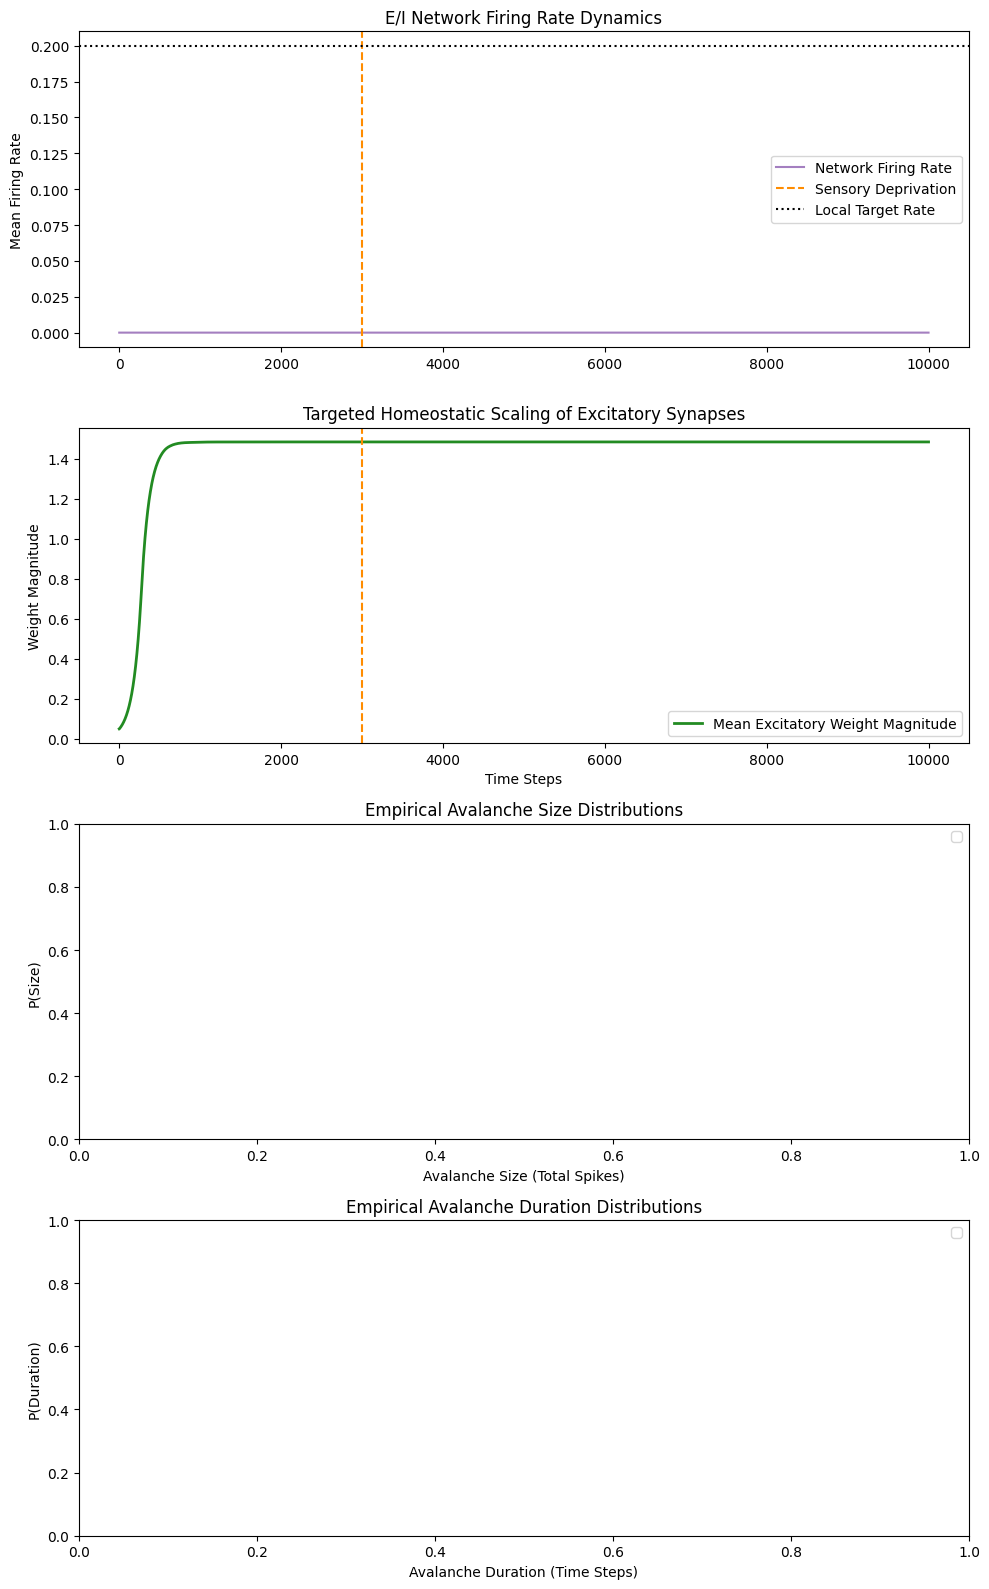

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. Parameter Setup & Biophysical Constraints
# -------------------------------------------------------------------------
np.random.seed(42)

N_E = 80                # Excitatory neurons
N_I = 20                # Inhibitory neurons
N = N_E + N_I           # Total network size

T = 10000               # Total simulation time steps
dt = 1                  # Time step (ms)
tau_m = 10              # Membrane time constant (ms)
tau_h = 500             # Local homeostatic integration window (ms)
eta = 0.01              # Homeostatic learning rate
r_target = 0.2          # Target individual neuron firing probability per ms
v_thr = 1.0             # Firing threshold
v_reset = 0.0           # Reset potential

t_deprivation = 3000    # Onset of sensory deprivation
t_recovery = 7000       # Monitoring period for homeostatic recovery

# Define masks for identity tracking
is_excitatory = np.zeros(N, dtype=bool)
is_excitatory[:N_E] = True
is_inhibitory = ~is_excitatory

# Initialize structural connectivity matrix using absolute magnitudes
W_mag = np.random.uniform(0.0, 0.1, (N, N))
np.fill_diagonal(W_mag, 0)

# Enforce true Dale's Law: create a signed matrix where presynaptic identity
# determines the sign of the entire column.
W = W_mag.copy()
W[:, is_inhibitory] *= -2.5  # Stronger initial inhibitory efficacy to balance populations

# Global state vectors
V = np.zeros(N)
firing_rates = np.zeros(N)  # Continuous low-pass local estimator
activity_history = np.zeros(T)
weight_history_E = np.zeros(T)
spike_history = np.zeros((N, T))

# Sensory inputs applied to the network
I_baseline = np.zeros(N)
I_baseline[is_excitatory] = 0.4
I_baseline[is_inhibitory] = 0.2

I_deprived = np.zeros(N)
I_deprived[is_excitatory] = 0.1  # Significant sensory loss
I_deprived[is_inhibitory] = 0.1

# -------------------------------------------------------------------------
# 2. Vectorized Simulation Loop
# -------------------------------------------------------------------------
for t in range(T):
    I_ext = I_baseline if t < t_deprivation else I_deprived
    noise = np.random.normal(0, 0.1, N)
    
    # Elegant dot product calculation made possible by signed matrix columns
    synaptic_input = W @ spike_history[:, t-1] if t > 0 else np.zeros(N)
        
    # Leaky Integrate-and-Fire update step
    dV = (-(V - v_reset) + I_ext + synaptic_input + noise) * (dt / tau_m)
    V += dV
    
    # Evaluate threshold crossings
    spikes = (V >= v_thr).astype(int)
    spike_history[:, t] = spikes
    V[spikes == 1] = v_reset
    
    # Update local homeostatic firing rate estimate
    firing_rates += (dt / tau_h) * (-firing_rates + spikes)
    
    # Metrics tracking
    activity_history[t] = np.mean(spikes)
    weight_history_E[t] = np.mean(np.abs(W[:, :N_E]))  # Track mean magnitude of E synapses
    
    # Targeted Multiplicative Homeostatic Scaling
    # Only incoming excitatory synapses are scaled by the local feedback error
    if t > 0:
        scaling = eta * (1.0 - (firing_rates / r_target))
        # Multiplicatively update only the excitatory columns of the matrix
        W[:, is_excitatory] *= (1.0 + scaling[:, None])
        
        # Enforce structural boundaries on magnitudes while maintaining signs
        W[:, is_excitatory] = np.clip(W[:, is_excitatory], 0.0, 1.5)
        W[:, is_inhibitory] = np.clip(W[:, is_inhibitory], -1.5, 0.0)
        np.fill_diagonal(W, 0)

# -------------------------------------------------------------------------
# 3. Dual Avalanche Parameter Evaluation (Size & Duration)
# -------------------------------------------------------------------------
def analyze_avalanches(spikes_matrix):
    pop_activity = np.sum(spikes_matrix, axis=0)
    sizes = []
    durations = []
    
    current_size = 0
    current_duration = 0
    in_avalanche = False
    
    for act in pop_activity:
        if act > 0:
            in_avalanche = True
            current_size += act
            current_duration += 1
        elif in_avalanche:
            sizes.append(current_size)
            durations.append(current_duration)
            current_size = 0
            current_duration = 0
            in_avalanche = False
            
    return sizes, durations

baseline_sizes, baseline_durs = analyze_avalanches(spike_history[:, :t_deprivation])
deprived_sizes, deprived_durs = analyze_avalanches(spike_history[:, t_deprivation:t_recovery])
recovered_sizes, recovered_durs = analyze_avalanches(spike_history[:, t_recovery:])

# -------------------------------------------------------------------------
# 4. Data Visualization
# -------------------------------------------------------------------------
fig, axes = plt.subplots(4, 1, figsize=(10, 16))

# Panel 1: Firing Rate Timelines
axes[0].plot(activity_history, color='indigo', alpha=0.5, label='Network Firing Rate')
axes[0].axvline(t_deprivation, color='darkorange', linestyle='--', label='Sensory Deprivation')
axes[0].axhline(r_target, color='black', linestyle=':', label='Local Target Rate')
axes[0].set_title('E/I Network Firing Rate Dynamics')
axes[0].set_ylabel('Mean Firing Rate')
axes[0].legend()

# Panel 2: Synaptic Weight Readouts
axes[1].plot(weight_history_E, color='forestgreen', linewidth=2, label='Mean Excitatory Weight Magnitude')
axes[1].axvline(t_deprivation, color='darkorange', linestyle='--')
axes[1].set_title('Targeted Homeostatic Scaling of Excitatory Synapses')
axes[1].set_xlabel('Time Steps')
axes[1].set_ylabel('Weight Magnitude')
axes[1].legend()

# Panel 3: Avalanche Size Distributions
for size_data, label, color in zip(
    [baseline_sizes, deprived_sizes, recovered_sizes],
    ['Baseline Epoch', 'Immediate Post-Deprivation', 'Post-Homeostatic Recovery'],
    ['teal', 'crimson', 'darkorchid']
):
    if len(size_data) > 0:
        sizes, counts = np.unique(size_data, return_counts=True)
        prob = counts / np.sum(counts)
        axes[2].loglog(sizes, prob, marker='o', linestyle='none', label=label, color=color, alpha=0.7)
axes[2].set_title('Empirical Avalanche Size Distributions')
axes[2].set_xlabel('Avalanche Size (Total Spikes)')
axes[2].set_ylabel('P(Size)')
axes[2].legend()

# Panel 4: Avalanche Duration Distributions
for dur_data, label, color in zip(
    [baseline_durs, deprived_durs, recovered_durs],
    ['Baseline Epoch', 'Immediate Post-Deprivation', 'Post-Homeostatic Recovery'],
    ['teal', 'crimson', 'darkorchid']
):
    if len(dur_data) > 0:
        durs, counts = np.unique(dur_data, return_counts=True)
        prob = counts / np.sum(counts)
        axes[3].loglog(durs, prob, marker='s', linestyle='none', label=label, color=color, alpha=0.7)
axes[3].set_title('Empirical Avalanche Duration Distributions')
axes[3].set_xlabel('Avalanche Duration (Time Steps)')
axes[3].set_ylabel('P(Duration)')
axes[3].legend()

plt.tight_layout()
plt.show()